# Caregiver Survey Response Screening

> **Note:** Screening rules identify responses that may need additional review. A triggered rule does not, by itself, prove that a response was submitted by a bot.

In [1]:
from pathlib import Path
import importlib

import matplotlib
matplotlib.use("agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

import bot_analysis as ba

ba = importlib.reload(ba)

%matplotlib inline
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 20)

project_dir = Path.cwd()
output_dir = project_dir / "Caregiver Outputs"
cache_dir = project_dir / "data_cache"

# ── Load data (uses today's cached copy or pulls fresh) ─────────────────
source_table = ba.refresh_redcap_cache(project_dir, cache_dir)
audit_table = ba.check_redcap_audit_access(project_dir)

# ── Build the canonical risk table and triage ───────────────────────────
risk_table = ba.build_risk_table(output_dir, cache_dir, project_dir)
triaged = ba.build_review_triage(risk_table)

# ── Executive KPIs ──────────────────────────────────────────────────────
kpis = ba.build_stakeholder_executive_summary(triaged)

display(Markdown(f"""
| Metric | Count |
|--------|------:|
| Known-real caregiver responses | {kpis['verified_total']:,} |
| Online sign-up responses | {kpis['online_total']:,} |
| Online responses cleared for payment | {kpis['pay_online']:,} |
| Online responses requiring review | {kpis['review_online']:,} |
| Online responses recommended not to pay | {kpis['reject_online']:,} |
| Known-real caregivers incorrectly refused (current policy) | {kpis['false_refusals']} |
| Held responses someone actually needs to open | {kpis['manual_reads_needed']} |
"""))

/Users/namomac/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



| Metric | Count |
|--------|------:|
| Known-real caregiver responses | 177 |
| Online sign-up responses | 1,779 |
| Online responses cleared for payment | 68 |
| Online responses requiring review | 1,032 |
| Online responses recommended not to pay | 679 |
| Known-real caregivers incorrectly refused (current policy) | 3 |
| Held responses someone actually needs to open | 61 |


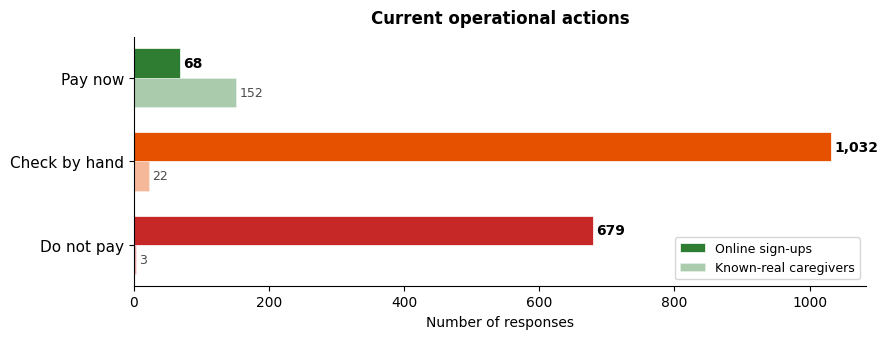

In [2]:
# ── Action summary chart ─────────────────────────────────────────────────
fig = ba.plot_stakeholder_action_summary(triaged)
plt.show()
plt.close(fig)

---

## How Screening Works

Every response is evaluated in three steps:

1. **Check against 14 screening signals.** Nine original rules (R1–R9) plus five supplemental checks (E1–E5).
2. **Each triggered signal adds points** according to its severity.
3. **The total score supports a payment or review recommendation.**

### Score formulas

Two scoring scales are carried side by side. Current operational decisions come from the operational scale unless stakeholders formally approve a different policy.

**Current operational score:**
> Serious rules × 2 + Mild rules × 1

**Proposed stakeholder score:**
> Serious rules × 5 + Mild rules × 1

### Current operational actions

| Operational score | Action |
|------------------:|--------|
| 0 | Pay now |
| 1–2 | Check by hand |
| 3 or more | Do not pay |

A `.edu` email address clears a held response, *unless* one of the contradiction checks fired (duplicate answer sheet, family contradiction, impossible demographics, or throwaway email).

In [3]:
# ── Compact rule key ─────────────────────────────────────────────────────
rule_key = ba.build_stakeholder_rule_key(triaged)
display(rule_key.style
    .set_caption("Screening rule reference")
    .apply(lambda row: [
        "background-color: #FFC7CE; color: #9C0006" if row["Severity"] == "Serious"
        else "background-color: #C6EFCE; color: #006100"
    ] * len(row), axis=1)
    .hide(axis="index"))

Code,Plain-language description,Category,Severity,Current operational points,Proposed stakeholder points,Known-real caregivers flagged,Online sign-ups flagged
R1,Whole survey finished faster than any verified caregiver,Survey timing,Serious,2,5,0,283
R2,Thoughts and feelings section faster than any verified caregiver,Survey timing,Serious,2,5,0,447
R3,One of the four sections finished below its own speed line,Survey timing,Mild,1,1,7,839
R4,The same answer repeated down a rating block,Response pattern,Mild,1,1,12,577
R5,Answer sheet identical to another response,Duplicate content,Serious,2,5,0,0
R6,Arrived within a minute of two or more other sign-ups,Arrival timing,Mild,1,1,6,1676
R7,Written comment nearly identical to another response,Duplicate content,Mild,1,1,0,17
R8,Family answers contradict each other,Family consistency,Serious,2,5,0,44
R9,Age and location cannot both be true,Demographics,Serious,2,5,2,0
E1,Whole survey time sits inside the uncertainty band,Survey timing,Mild,1,1,3,104


---

## Main Results

### Current action counts

,Recommended action,Verified caregivers,Online sign-ups,All responses,Share of all responses,What this means
0,Pay now,152,68,220,11.2%,No points. Send the gift card.
1,Check by hand,22,1032,1054,53.9%,One or two points. A person should look before paying.
2,Do not pay,3,679,682,34.9%,3 points or more. Refuse payment.


### Score distribution (current operational scale)

,Risk score,Verified caregivers,Online sign-ups,All responses,Recommended action
0,0,151,66,217,Pay now
1,1,18,658,676,Check by hand
2,2,5,375,380,Check by hand
3,3,2,149,151,Do not pay
4,4,1,107,108,Do not pay
5,5,0,114,114,Do not pay
6,6,0,187,187,Do not pay
7,7,0,115,115,Do not pay
8,8,0,5,5,Do not pay
9,9,0,3,3,Do not pay


### How often each screening signal fires

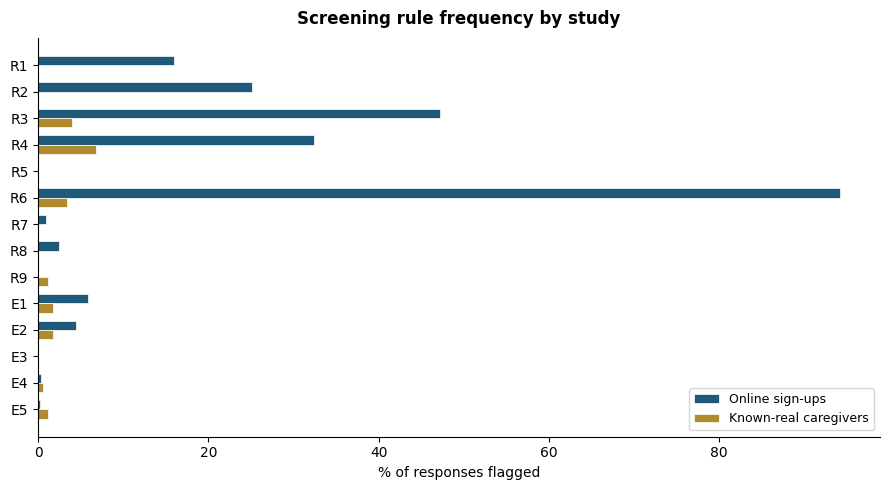

> **R6** fires on 94% of online sign-ups and 3% of known-real caregivers. A high study-level rate may reflect recruitment or data-collection conditions and should not automatically be interpreted as evidence against any individual response.

> **R6 (arrival timing)** is a contextual or channel-level signal. It describes the traffic pattern on a given day, not what an individual person did. It should not be described as conclusive evidence against an individual response.

In [4]:
# ── A. Current action counts for online sign-ups ────────────────────────
display(Markdown("### Current action counts"))
display(ba.build_action_summary_table(risk_table))

# ── B. Score distribution under the current operational scale ────────────
display(Markdown("### Score distribution (current operational scale)"))
display(ba.build_score_distribution_table(risk_table))

# ── C. Rule frequency by study ──────────────────────────────────────────
display(Markdown("### How often each screening signal fires"))
fig_freq = ba.plot_stakeholder_rule_frequency(triaged)
plt.show()
plt.close(fig_freq)

# Narrative interpretation of high-rate rules
high_rate = getattr(fig_freq, "_high_rate_rules", [])
if high_rate:
    for hr in high_rate:
        display(Markdown(
            f"> **{hr['code']}** fires on {hr['online_rate']:.0f}% of online sign-ups"
            f" and {hr['verified_rate']:.0f}% of known-real caregivers. "
            f"A high study-level rate may reflect recruitment or data-collection conditions "
            f"and should not automatically be interpreted as evidence against any individual response."
        ))

# Interpret the arrival-timing rule specifically
display(Markdown(
    "> **R6 (arrival timing)** is a contextual or channel-level signal. "
    "It describes the traffic pattern on a given day, not what an individual person did. "
    "It should not be described as conclusive evidence against an individual response."
))

---

## Record-Level Results

The table below shows the rules each response violated, the scores under both scales, and the current operational action. The complete table is in the exported workbook.

In [5]:
# ── Build the stakeholder rule list ──────────────────────────────────────
rules_list = ba.build_stakeholder_rule_list(triaged)

# Preview: top 15 highest-scoring online sign-ups
online_list = rules_list[rules_list["Study"].eq(ba.PROJECT_LABELS["dirty_4581"])]
display(Markdown("### Highest-scoring online sign-ups (preview)"))
preview_cols = [c for c in rules_list.columns if "email" not in c.lower()]
display(online_list[preview_cols].head(15))

# Preview: known-real caregivers placed in "Do not pay" or "Check by hand"
verified_flagged = rules_list[
    rules_list["Study"].eq(ba.PROJECT_LABELS["clean_4797"])
    & rules_list[ba.OPERATIONAL_ACTION_COLUMN].isin([ba.ACTION_REJECT, ba.ACTION_REVIEW])
]
if not verified_flagged.empty:
    display(Markdown(
        f"### Known-real caregivers with current action ≠ Pay now "
        f"({len(verified_flagged):,} responses)"
    ))
    display(verified_flagged[preview_cols].head(10))
else:
    display(Markdown("*All known-real caregivers are currently cleared for payment.*"))

display(Markdown(
    f"**Complete table:** {len(rules_list):,} responses across both studies. "
    "See the exported Excel workbook for the full record."
))

### Highest-scoring online sign-ups (preview)

,Study,Record ID,Response key,Rules violated,"Rules violated, in plain language",Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Proposed stakeholder score (Mild = 1, Serious = 5)","Current operational score (Mild = 1, Serious = 2)",Current operational action,Final review plan
177,Study 2 - online recruitment sample,1026,4581-1026,"R1, R2, R3, R4, R6, R8",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,3,3,18,9,Do not pay,Do not pay
178,Study 2 - online recruitment sample,120,4581-120,"R1, R2, R3, R4, R6, R8",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,3,3,18,9,Do not pay,Do not pay
179,Study 2 - online recruitment sample,571,4581-571,"R1, R2, R3, R4, R6, R8",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,3,3,18,9,Do not pay,Do not pay
180,Study 2 - online recruitment sample,1119,4581-1119,"R1, R2, R3, R4, R6, R7",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,2,4,14,8,Do not pay,Do not pay
181,Study 2 - online recruitment sample,1120,4581-1120,"R1, R2, R3, R4, R6, R7",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,2,4,14,8,Do not pay,Do not pay
182,Study 2 - online recruitment sample,1330,4581-1330,"R1, R2, R3, R4, R6, R7",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,2,4,14,8,Do not pay,Do not pay
183,Study 2 - online recruitment sample,1332,4581-1332,"R1, R2, R3, R4, R6, R7",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,2,4,14,8,Do not pay,Do not pay
184,Study 2 - online recruitment sample,945,4581-945,"R1, R2, R3, R4, R6, R7",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,2,4,14,8,Do not pay,Do not pay
185,Study 2 - online recruitment sample,1006,4581-1006,"R1, R2, R3, R4, R6",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,5,2,3,13,7,Do not pay,Do not pay
186,Study 2 - online recruitment sample,1048,4581-1048,"R1, R2, R3, R4, R6",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,5,2,3,13,7,Do not pay,Do not pay


### Known-real caregivers with current action ≠ Pay now (25 responses)

,Study,Record ID,Response key,Rules violated,"Rules violated, in plain language",Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Proposed stakeholder score (Mild = 1, Serious = 5)","Current operational score (Mild = 1, Serious = 2)",Current operational action,Final review plan
0,Study 1 - verified caregiver sample,101,4797-101,"R9, E5",Age and location cannot both be true; Started between midnight and five in the morning,2,1,1,6,3,Do not pay,Do not pay
1,Study 1 - verified caregiver sample,89,4797-89,R9,Age and location cannot both be true,1,1,0,5,2,Check by hand,Read every one by hand
2,Study 1 - verified caregiver sample,143,4797-143,"R3, R4, E1, E2",One of the four sections finished below its own speed line; The same answer repeated d...,4,0,4,4,4,Do not pay,Do not pay
3,Study 1 - verified caregiver sample,168,4797-168,"R3, E1, E2",One of the four sections finished below its own speed line; Whole survey time sits ins...,3,0,3,3,3,Do not pay,Do not pay
4,Study 1 - verified caregiver sample,157,4797-157,"R3, E2",One of the four sections finished below its own speed line; Thoughts and feelings time...,2,0,2,2,2,Check by hand,Read a random sample by hand
5,Study 1 - verified caregiver sample,18,4797-18,"R4, R6",The same answer repeated down a rating block; Arrived within a minute of two or more o...,2,0,2,2,2,Check by hand,Read a random sample by hand
6,Study 1 - verified caregiver sample,40,4797-40,"R3, R6",One of the four sections finished below its own speed line; Arrived within a minute of...,2,0,2,2,2,Check by hand,Read a random sample by hand
7,Study 1 - verified caregiver sample,92,4797-92,"R3, E1",One of the four sections finished below its own speed line; Whole survey time sits ins...,2,0,2,2,2,Check by hand,Read a random sample by hand
8,Study 1 - verified caregiver sample,122,4797-122,E5,Started between midnight and five in the morning,1,0,1,1,1,Check by hand,"Release, slower than a typical verified caregiver"
9,Study 1 - verified caregiver sample,128,4797-128,R4,The same answer repeated down a rating block,1,0,1,1,1,Check by hand,"Release, slower than a typical verified caregiver"


**Complete table:** 1,956 responses across both studies. See the exported Excel workbook for the full record.

---

## Filterable Rule Grid

The grid layout puts a separate Yes/No column for each of the 14 rules, making it easy to filter, sort, and audit in Excel.

- **List layout** (above): easiest to read one response at a time.
- **Grid layout** (below): easiest to filter by a single rule or count rule co-occurrences.

In [6]:
rules_grid = ba.build_stakeholder_rule_grid(triaged)
display(Markdown(f"Grid: {len(rules_grid):,} rows × {rules_grid.shape[1]} columns"))
display(rules_grid.head(8))

Grid: 1,956 rows × 24 columns

,Study,Record ID,Response key,R1,R2,R3,R4,R5,R6,R7,...,E3,E4,E5,Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Proposed stakeholder score (Mild = 1, Serious = 5)","Current operational score (Mild = 1, Serious = 2)",Current operational action,Final review plan
0,Study 1 - verified caregiver sample,101,4797-101,No,No,No,No,No,No,No,...,No,No,Yes,2,1,1,6,3,Do not pay,Do not pay
1,Study 1 - verified caregiver sample,89,4797-89,No,No,No,No,No,No,No,...,No,No,No,1,1,0,5,2,Check by hand,Read every one by hand
2,Study 1 - verified caregiver sample,143,4797-143,No,No,Yes,Yes,No,No,No,...,No,No,No,4,0,4,4,4,Do not pay,Do not pay
3,Study 1 - verified caregiver sample,168,4797-168,No,No,Yes,No,No,No,No,...,No,No,No,3,0,3,3,3,Do not pay,Do not pay
4,Study 1 - verified caregiver sample,157,4797-157,No,No,Yes,No,No,No,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand
5,Study 1 - verified caregiver sample,18,4797-18,No,No,No,Yes,No,Yes,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand
6,Study 1 - verified caregiver sample,40,4797-40,No,No,Yes,No,No,Yes,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand
7,Study 1 - verified caregiver sample,92,4797-92,No,No,Yes,No,No,No,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand


---

## Validation and Policy Sensitivity

The known-real caregiver group (Study 1) serves as a reference for checking the screening rules. Some timing thresholds were derived from this group, so it is a known-real reference group — not a perfectly independent validation set.

### Current operational actions among known-real caregivers

In [7]:
# ── 1. Current operational actions for known-real caregivers ─────────────
display(ba.build_false_alarm_summary(risk_table))

# ── 2. Details of any known-real caregiver that would be refused ─────────
wrongly_refused = ba.build_wrongly_refused_detail(risk_table)
if not wrongly_refused.empty:
    display(Markdown(
        f"**{len(wrongly_refused)} known-real caregiver(s) would currently be refused:**"
    ))
    display(wrongly_refused)
else:
    display(Markdown("*No known-real caregiver is currently refused.*"))

# ── 3. Cutoff sensitivity: operational 1/2 scale ────────────────────────
display(Markdown(
    "### Cutoff sensitivity — Current operational score (Mild = 1, Serious = 2)"
))
op_sensitivity = ba.build_operational_cutoff_sensitivity(triaged)
display(op_sensitivity)

# ── 4. Cutoff sensitivity: proposed 1/5 scale ───────────────────────────
display(Markdown(
    "### Cutoff sensitivity — Proposed stakeholder score (Mild = 1, Serious = 5)"
))
sh_sensitivity = ba.build_stakeholder_cutoff_sensitivity(triaged)
display(sh_sensitivity)

candidate = sh_sensitivity.attrs.get("first_zero_refusal_cutoff")
if candidate is not None:
    display(Markdown(
        f"> **Candidate cutoff for stakeholder discussion:** "
        f"A cutoff of **{candidate}** on the proposed 1/5 scale is the lowest tested value "
        f"that produces zero refusals among the known-real caregiver reference group. "
        f"This is a candidate for discussion — **not an approved policy.**"
    ))

display(Markdown(
    "> **Tradeoff:** Raising the cutoff catches fewer questionable responses but also "
    "reduces the risk of incorrectly refusing a known-real caregiver. "
    "Lowering the cutoff catches more questionable responses but increases false refusals."
))

,Recommended action,Verified caregivers,Share of the 177 verified caregivers
0,Pay now,152,85.9%
1,Check by hand,22,12.4%
2,Do not pay,3,1.7%


**3 known-real caregiver(s) would currently be refused:**

,Record ID,Whole survey minutes,Thoughts and feelings minutes,Whole survey speed,Thoughts and feelings speed,Which checks were broken,Risk score,Recommended action
0,143,12.05,7.85,Possibly rushed,Possibly rushed,Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,4,Do not pay
1,101,23.67,17.90,Normal,Normal,Age and location cannot both be true; Started between midnight and five in the morning,3,Do not pay
2,168,12.19,8.52,Possibly rushed,Possibly rushed,Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,3,Do not pay


### Cutoff sensitivity — Current operational score (Mild = 1, Serious = 2)

,Cutoff,Scale,Online sign-ups refused,% of online sign-ups refused,Known-real caregivers refused,% of known-real caregivers refused,Plain-language interpretation,Status
0,1,"Current operational (Mild = 1, Serious = 2)",1713,96.3%,26,14.7%,Any check at all means refusal,Scenario only
1,2,"Current operational (Mild = 1, Serious = 2)",1055,59.3%,8,4.5%,"Any two mild checks, or any serious check, means refusal",Scenario only
2,3,"Current operational (Mild = 1, Serious = 2)",680,38.2%,3,1.7%,"Three mild checks, or one serious plus one mild",Currently in use
3,4,"Current operational (Mild = 1, Serious = 2)",531,29.8%,1,0.6%,"Two serious checks, or one serious plus two mild",Scenario only
4,5,"Current operational (Mild = 1, Serious = 2)",424,23.8%,0,0.0%,"Two serious checks plus one mild, or five mild",Scenario only
5,6,"Current operational (Mild = 1, Serious = 2)",310,17.4%,0,0.0%,"Three serious checks, or two serious plus two mild",Scenario only
6,7,"Current operational (Mild = 1, Serious = 2)",123,6.9%,0,0.0%,Three serious checks plus one mild,Scenario only


### Cutoff sensitivity — Proposed stakeholder score (Mild = 1, Serious = 5)

,Cutoff,Scale,Online sign-ups refused,% of online sign-ups refused,Known-real caregivers refused,% of known-real caregivers refused,Plain-language interpretation,Status
0,3,"Proposed stakeholder (Mild = 1, Serious = 5)",682,38.3%,4,2.3%,"Refuses any three mild rules, and any single serious rule","Same number as the operational cutoff, but much harsher on this scale"
1,5,"Proposed stakeholder (Mild = 1, Serious = 5)",497,27.9%,2,1.1%,Refuses any single serious rule on its own,Scenario only
2,6,"Proposed stakeholder (Mild = 1, Serious = 5)",487,27.4%,1,0.6%,Refuses a serious rule once anything else joins it,Scenario only
3,7,"Proposed stakeholder (Mild = 1, Serious = 5)",480,27.0%,0,0.0%,"Refuses a serious rule with two mild ones, or two serious rules",Candidate cutoff for stakeholder discussion; not an approved policy
4,8,"Proposed stakeholder (Mild = 1, Serious = 5)",416,23.4%,0,0.0%,"Refuses a serious rule with three mild ones, or two serious rules",Scenario only
5,10,"Proposed stakeholder (Mild = 1, Serious = 5)",283,15.9%,0,0.0%,Refuses two serious rules,Scenario only
6,12,"Proposed stakeholder (Mild = 1, Serious = 5)",281,15.8%,0,0.0%,Refuses two serious rules with two mild ones,Scenario only


> **Candidate cutoff for stakeholder discussion:** A cutoff of **7** on the proposed 1/5 scale is the lowest tested value that produces zero refusals among the known-real caregiver reference group. This is a candidate for discussion — **not an approved policy.**

> **Tradeoff:** Raising the cutoff catches fewer questionable responses but also reduces the risk of incorrectly refusing a known-real caregiver. Lowering the cutoff catches more questionable responses but increases false refusals.

---

## Review Workload

Not every held response requires someone to open it. The triage below separates the "check by hand" pile by the *kind* of evidence against each response.

In [8]:
triage_summary = ba.build_triage_summary(triaged)
display(triage_summary)

display(Markdown(
    f"**Total initially held:** {triage_summary.attrs.get('held_total', '—'):,}  \n"
    f"**Responses someone actually reads:** {triage_summary.attrs.get('total_read', '—')}  \n\n"
    "The remaining held responses can be released automatically after contextual triage "
    "(arrival timing only, or slower than a typical verified caregiver), or are waiting for "
    "an unfinished-survey policy decision."
))

,Review plan,Online sign-ups,Share of the held pile,Middle survey time (minutes),Responses a person actually reads,Why
0,"Release, arrival timing only",544,52.7%,30.87,0,"The only check against this response was arrival timing, and that check is about the d..."
1,"Release, slower than a typical verified caregiver",145,14.1%,36.85,0,"Only mild checks fired, and this response spent longer on the survey than the typical ..."
2,Read a random sample by hand,249,24.1%,19.27,59,"Only mild checks fired, but this response finished faster than the typical verified ca..."
3,Read every one by hand,2,0.2%,32.34,2,"A serious check fired that describes what this person answered, not when they arrived."
4,Hold until the completion rule is set,92,8.9%,no time recorded,0,"No section of this response has a recorded time, so no timing check can reach it. This..."


**Total initially held:** 1,032  
**Responses someone actually reads:** 61  

The remaining held responses can be released automatically after contextual triage (arrival timing only, or slower than a typical verified caregiver), or are waiting for an unfinished-survey policy decision.

---

## Decisions Needed Before Payment

> **These are policy decisions, not coding decisions.**

1. **Does an unfinished survey qualify for a gift card?**
2. **Should the operational score remain Mild = 1, Serious = 2, or change to Mild = 1, Serious = 5?**
3. **What refusal cutoff should apply to the selected scale?**
4. **Should arrival timing (R6) remain a scored individual rule, become contextual evidence only, or be removed from individual scoring?**

In [9]:
# ── Export the stakeholder workbook (no email addresses) ─────────────────
stakeholder_workbook = ba.export_stakeholder_screening_workbook(
    triaged=triaged,
    output_dir=output_dir,
)
display(Markdown(
    f"**Stakeholder workbook:** "
    f"[{stakeholder_workbook.relative_to(project_dir)}]"
    f"(file:///{stakeholder_workbook})"
))
display(Markdown(f"Sheets: {pd.ExcelFile(stakeholder_workbook).sheet_names}"))

# ── Export the restricted master workbook (with email addresses) ─────────
master_workbook = ba.export_master_workbook(
    output_dir=output_dir,
    cache_dir=cache_dir,
    project_dir=project_dir,
    source_table=source_table,
    audit_table=audit_table,
)
display(Markdown(
    f"**Restricted master workbook:** "
    f"[{master_workbook.relative_to(project_dir)}]"
    f"(file:///{master_workbook})"
))

**Stakeholder workbook:** [Caregiver Outputs/ESD_Response_Screening_Stakeholder_View.xlsx](file:////Users/namomac/esd-redcap-metadata-watcher/projects/caregiver-cluster-analysis/Caregiver Outputs/ESD_Response_Screening_Stakeholder_View.xlsx)

Sheets: ['Executive Summary', 'Record Rule Summary', 'Rule Grid', 'Rule Key', 'Policy Sensitivity']

**Restricted master workbook:** [Caregiver Outputs/restricted/ESD_Response_Review_Master.xlsx](file:////Users/namomac/esd-redcap-metadata-watcher/projects/caregiver-cluster-analysis/Caregiver Outputs/restricted/ESD_Response_Review_Master.xlsx)

---

## Technical Appendix

*Optional reading. The sections below contain detailed diagnostics that support the screening rules above but are not needed for stakeholder decisions.*

In [10]:
# ── Threshold verification ───────────────────────────────────────────────
display(Markdown("### Threshold verification"))
threshold_check = ba.build_threshold_check_table(output_dir, cache_dir)
display(threshold_check)

# ── Time limit confidence bands ─────────────────────────────────────────
display(Markdown("### Time limit confidence bands"))
bands = ba.build_time_limit_bands(output_dir, cache_dir)
display(bands)

# ── Score simulation (what happens if the refusal line moves) ────────────
display(Markdown("### Score simulation — current operational scale"))
display(ba.build_score_simulation_table(risk_table))

# ── Scale comparison ────────────────────────────────────────────────────
display(Markdown("### Scale comparison"))
display(ba.build_scale_comparison(triaged))

# ── Arrival timing by day ───────────────────────────────────────────────
display(Markdown("### Arrival timing by day"))
display(ba.build_arrival_by_day_table(risk_table))

# ── REDCap data sources ─────────────────────────────────────────────────
display(Markdown("### Data sources"))
display(source_table)

display(Markdown("### Audit trail access"))
display(audit_table)

### Threshold verification

,What we check,How the line is worked out,Line used in the report (minutes),Line recomputed here (minutes),Do they match
0,Whole survey too fast,smallest whole-survey time,11.570,11.570,Yes
1,Attitudes section too fast,smallest attitudes time,7.850,7.850,Yes
2,Family Information section rushed,1st percentile of verified times,0.786,0.786,Yes
3,Values section rushed,1st percentile of verified times,0.680,0.680,Yes
4,Attitudes section rushed,1st percentile of verified times,8.568,8.568,Yes
5,Demographics section rushed,1st percentile of verified times,1.100,1.100,Yes


### Time limit confidence bands

,Part of the survey,How the limit was set,Limit in use (minutes),Limit in use,Band runs from (minutes),Band runs to (minutes),Below the band,Inside the band
0,Whole survey,Fastest verified caregiver,11.57,11 minutes 34 seconds,11.57,13.20,Definitely rushed,Possibly rushed
1,Thoughts and feelings section,Fastest verified caregiver,7.85,7 minutes 51 seconds,7.85,8.77,Definitely rushed,Possibly rushed
2,Family Information section,Slowest 1 in 100 verified caregivers,0.79,47 seconds,0.68,0.91,Definitely rushed,Possibly rushed
3,Values section,Slowest 1 in 100 verified caregivers,0.68,41 seconds,0.67,0.82,Definitely rushed,Possibly rushed
4,Demographics section,Slowest 1 in 100 verified caregivers,1.10,1 minute 6 seconds,0.72,1.30,Definitely rushed,Possibly rushed


### Score simulation — current operational scale

...

,Day,Sign-ups that day,Arrived in a burst,Share of that day
0,2025-09-03,1,0,0.0%
1,2025-09-04,23,0,0.0%
2,2025-09-05,33,0,0.0%
3,2025-09-06,1722,1676,97.3%
4,All verified caregivers,177,6,3.4%


### Data sources

,Study,Project number,What was pulled,Rows,Where it came from,Saved as
0,Study 1 - verified caregiver sample,4797,"Every answer, including survey timing fields",177,"Saved copy from today, checksum verified",4797_record_2026-09-15.parquet
1,Study 1 - verified caregiver sample,4797,Field list and branching rules,324,"Saved copy from today, checksum verified",4797_metadata_2026-09-15.parquet
2,Study 1 - verified caregiver sample,4797,Section list,5,"Saved copy from today, checksum verified",4797_instrument_2026-09-15.parquet
3,Study 2 - online recruitment sample,4581,"Every answer, including survey timing fields",1779,"Saved copy from today, checksum verified",4581_record_2026-09-15.parquet
4,Study 2 - online recruitment sample,4581,Field list and branching rules,315,"Saved copy from today, checksum verified",4581_metadata_2026-09-15.parquet
5,Study 2 - online recruitment sample,4581,Section list,5,"Saved copy from today, checksum verified",4581_instrument_2026-09-15.parquet


### Audit trail access

,Study,What we asked for,Result,What came back
0,Study 1 - verified caregiver sample,"Audit trail (who changed what, and when)",Not available to this key,"The API request cannot complete because currently you do not have ""Logging"" privileges..."
1,Study 1 - verified caregiver sample,Survey invitation list,Not available to this key,"The API request cannot complete because currently you do not have ""Manage Survey Parti..."
2,Study 2 - online recruitment sample,"Audit trail (who changed what, and when)",Not available to this key,"The API request cannot complete because currently you do not have ""Logging"" privileges..."
3,Study 2 - online recruitment sample,Survey invitation list,Not available to this key,"The API request cannot complete because currently you do not have ""Manage Survey Parti..."
